# Lab 3 Solution: From Random Numbers to Random Variables

TA reference notebook. All results use NumPy's default generator with seed `211`. Small differences are acceptable when a student uses a different, clearly documented random-stream convention.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 211
N = 1000
plt.style.use("seaborn-v0_8-whitegrid")

## Part A: Generate Exponential Service Times

For mean service time `3.0`, the exponential rate is `1 / 3`. Apply `X = -log(1-U) / lambda` to 1,000 uniform values.

In [2]:
rng = np.random.default_rng(SEED)
mean_service = 3.0
lambda_rate = 1 / mean_service
u = rng.random(N)
service_inverse = -np.log1p(-u) / lambda_rate

inverse_summary = pd.DataFrame({
    "Mean": [service_inverse.mean()],
    "Standard deviation": [service_inverse.std(ddof=1)],
    "Minimum": [service_inverse.min()],
    "Maximum": [service_inverse.max()],
    "All non-negative?": [np.all(service_inverse >= 0)],
}, index=["Inverse transform"])

inverse_summary.round(4)

,Mean,Standard deviation,Minimum,Maximum,All non-negative?
Inverse transform,3.0464,3.1839,0.0065,20.0137,True


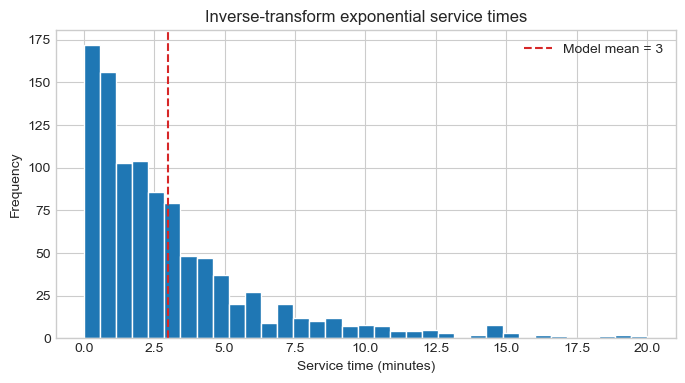

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(service_inverse, bins=35, edgecolor="white")
plt.axvline(mean_service, color="tab:red", linestyle="--", label="Model mean = 3")
plt.xlabel("Service time (minutes)")
plt.ylabel("Frequency")
plt.title("Inverse-transform exponential service times")
plt.legend()
plt.show()

**Answer:** all generated times are non-negative. The distribution is right-skewed: most services are short, but a few are much longer. Those long services matter because they can delay every customer waiting behind them. Inverse transform converts a uniform cumulative probability into a value from the target distribution.

## Part B: Confirm Against NumPy's Generator

In [5]:
rng = np.random.default_rng(SEED)
service_numpy = rng.exponential(scale=mean_service, size=N)

assert service_inverse.size == N and service_numpy.size == N
assert np.isclose(service_inverse.mean(), service_numpy.mean(), rtol=0.15)
print(f"Inverse-transform sample mean : {service_inverse.mean():.4f}")
print(f"NumPy sample mean             : {service_numpy.mean():.4f}")
print(f"Model mean (mean_service)     : {mean_service:.4f}")
print("Check passed: both samples are consistent with Exponential(mean=3.0).")

method_comparison = pd.DataFrame({
    "Method": ["Inverse transform", "NumPy generator"],
    "Mean": [service_inverse.mean(), service_numpy.mean()],
    "Standard deviation": [service_inverse.std(ddof=1), service_numpy.std(ddof=1)],
    "Minimum": [service_inverse.min(), service_numpy.min()],
    "Maximum": [service_inverse.max(), service_numpy.max()],
})

method_comparison.round(4)

,Method,Mean,Standard deviation,Minimum,Maximum
0,Inverse transform,3.0464,3.1839,0.0065,20.0137
1,NumPy generator,2.9718,2.9180,0.0027,20.7736


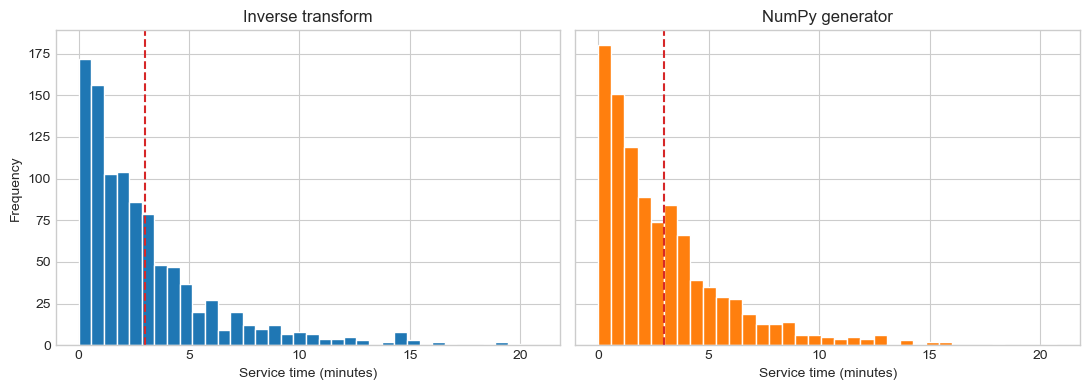

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
axes[0].hist(service_inverse, bins=35, edgecolor="white")
axes[0].set_title("Inverse transform")
axes[1].hist(service_numpy, bins=35, edgecolor="white", color="tab:orange")
axes[1].set_title("NumPy generator")
for ax in axes:
    ax.axvline(mean_service, color="tab:red", linestyle="--")
    ax.set_xlabel("Service time (minutes)")
axes[0].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

**Reference response:** exact equality is inappropriate because the manual and package generators transform or consume the random stream differently, so sampling variation is expected. A tolerance checks distributional consistency while allowing ordinary noise. A difference near 50% would be too large for these samples and would suggest a coding or parameterisation error, especially confusing the exponential mean (`scale`) with the rate.

## Part C: Use Accept-Reject Sampling

For target density `f(x) = 2x` on `[0,1]`, propose `x` and `u` independently from `Uniform(0,1)` and accept `x` when `u <= x`.

In [ ]:
rng = np.random.default_rng(SEED)
target_accepts = 1000
accepted = []
proposals = 0

while len(accepted) < target_accepts:
    x = rng.random()
    u_accept = rng.random()
    proposals += 1
    if u_accept <= x:
        accepted.append(x)

accepted = np.asarray(accepted)
acceptance_rate = len(accepted) / proposals
accepted_mean = accepted.mean()

accept_reject_summary = pd.DataFrame({
    "Accepted values": [len(accepted)],
    "Proposals": [proposals],
    "Acceptance rate": [acceptance_rate],
    "Sample mean": [accepted_mean],
})
accept_reject_summary.round(4)

In [ ]:
density_x = np.linspace(0, 1, 300)
plt.figure(figsize=(8, 4))
plt.hist(accepted, bins=30, range=(0, 1), density=True, edgecolor="white", alpha=0.7, label="Accepted sample")
plt.plot(density_x, 2 * density_x, color="tab:red", linewidth=2, label=r"Target $f(x)=2x$")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Accept-reject sample")
plt.legend()
plt.show()

**Answer:** the histogram rises toward 1 because larger proposals have a higher acceptance probability. Rejected proposals are an intended part of the algorithm, not mistakes. The reference run accepts 1,000 values from 2,053 proposals, giving rate `0.4871` and mean `0.6744`; theory gives acceptance rate `1/2` and mean `2/3`. Efficiency falls when the acceptance rule is rarely satisfied.

## Checkpoint 1: TA Reference

Award the first point when Parts A-C are complete and executed: 1,000 inverse-transform values, a passed manual-versus-NumPy consistency check with a sensible written response, and 1,000 accepted values with correct proposal accounting. Ask the student to explain either the exponential shape or why rejection changes the proposal distribution.

## Part D: Simulate Drink Orders and Service Times

In [ ]:
drinks = np.array(["Coffee", "Tea", "Chocolate", "Matcha"])
baseline_probabilities = np.array([0.35, 0.20, 0.30, 0.15])
mean_service_by_drink = {
    "Coffee": 2.0,
    "Tea": 1.5,
    "Chocolate": 4.0,
    "Matcha": 5.0,
}

rng = np.random.default_rng(SEED)
baseline_cut_points = np.cumsum(baseline_probabilities)
choice_u = rng.random(N)
baseline_drink_index = np.searchsorted(baseline_cut_points, choice_u, side="left")
baseline_drink_index = np.clip(baseline_drink_index, 0, len(drinks) - 1)
baseline_orders = drinks[baseline_drink_index]

service_u = rng.random(N)
baseline_means = np.array([mean_service_by_drink[drink] for drink in baseline_orders])
baseline_service = -np.log1p(-service_u) * baseline_means

baseline_data = pd.DataFrame({
    "Drink": baseline_orders,
    "Service time": baseline_service,
})
baseline_data.head(10)

In [ ]:
baseline_summary = (
    baseline_data.groupby("Drink")
    .agg(
        Count=("Drink", "size"),
        Average_service_time=("Service time", "mean"),
    )
    .reindex(drinks)
)
baseline_summary["Simulated proportion"] = baseline_summary["Count"] / N
baseline_summary = baseline_summary[["Count", "Simulated proportion", "Average_service_time"]]
baseline_summary.round(4)

In [ ]:
baseline_average = baseline_service.mean()
baseline_longest = baseline_service.max()

pd.DataFrame({
    "Overall average service time": [baseline_average],
    "Longest service time": [baseline_longest],
}).round(4)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
baseline_summary["Count"].plot.bar(ax=axes[0], color="tab:blue")
axes[0].set_title("Baseline drink counts")
axes[0].set_ylabel("Customers")
baseline_summary["Average_service_time"].plot.bar(ax=axes[1], color="tab:orange")
axes[1].set_title("Average service time by drink")
axes[1].set_ylabel("Minutes")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**Answer:** simulated proportions differ slightly from the input probabilities because the orders are a finite random sample. Matcha has the largest service-time mean, although total workload depends on both frequency and duration. Drink choice must be generated first because it determines the exponential mean for that customer. A discrete CDF is step-shaped and has no ordinary inverse; `searchsorted` implements its generalised inverse by selecting the first cumulative cut point at or above each uniform value.

## Part E: Reflect on a Matcha Trend

No new random sample is generated. Compare the scenarios through $E[T] = \sum_j p_j \mu_j$.

In [ ]:
trend_probabilities = np.append(
    baseline_probabilities[:3] * (0.65 / 0.85),
    0.35,
)
drink_means = np.array([mean_service_by_drink[drink] for drink in drinks])
baseline_expected_service = baseline_probabilities @ drink_means
trend_expected_service = trend_probabilities @ drink_means
expected_increase = trend_expected_service - baseline_expected_service
expected_percent_increase = 100 * expected_increase / baseline_expected_service

expectation_comparison = pd.DataFrame({
    "Scenario": ["Baseline", "Matcha trend"],
    "Expected service time": [baseline_expected_service, trend_expected_service],
    "Change from baseline": [0.0, expected_increase],
})
expectation_comparison.round(4)

In [ ]:
pd.DataFrame({
    "Expected increase (minutes)": [expected_increase],
    "Expected increase (%)": [expected_percent_increase],
}).round(4)

**Reference responses:** the theoretical expected service time rises from `2.9500` to `3.4324` minutes, an increase of `0.4824` minutes or about `16.35%`, because probability shifts toward Matcha, the drink with the largest mean. The longest observed value need not rise: a sample maximum is highly variable, whereas the expectation is a model average. Before acting, the manager should verify the new drink proportions, drink-specific preparation-time distributions, arrival rates, peak-period patterns, and whether staffing or preparation procedures change those times.

## Manager Recommendation

Prepare for the increased matcha workload before promoting the trend during peak periods. Test pre-batched ingredients, a dedicated preparation position, or cross-training another worker. Collect observed preparation times and arrival rates before choosing staffing levels, then evaluate the queue consequences in the later discrete-event model.

## Checkpoint 2: TA Reference

The final notebook should include the drink-level summary, expectation calculations, all three Part E responses, manager recommendation, and an honest AI-use statement. The student should connect the changed drink mix to expected workload without claiming that this input model directly calculates queue length.

## Three-Point Check

| Point | Evidence |
|---:|---|
| 1 | Correct and executed Parts A-C at Checkpoint 1 |
| 2 | Correct discrete inverse-transform drink simulation and drink-level summary |
| 3 | Student explains one generation method and gives an evidence-based manager recommendation |

## Suggested Oral Questions

- Why is NumPy's exponential `scale` equal to the mean rather than the rate?
- What does inverse transform do to a uniform value?
- Why does the Part B check use a tolerance rather than exact equality?
- Why do rejected proposals count when calculating efficiency?
- Why must drink choice be generated before service time?
- How does `searchsorted` act as a discrete inverse CDF?
- Why can an expectation rise even if a future sample maximum does not?
- Which evidence supports the manager recommendation?

## Instructor Verification

In [ ]:
assert len(service_inverse) == N
assert np.all(service_inverse >= 0)
assert np.isclose(service_inverse.mean(), 3.046409530113404)
assert np.isclose(service_numpy.mean(), 2.97182132292216)
assert proposals == 2053
assert np.isclose(acceptance_rate, 0.4870920603994155)
assert np.allclose(baseline_cut_points, [0.35, 0.55, 0.85, 1.0])
assert baseline_summary["Count"].to_dict() == {"Coffee": 352, "Tea": 207, "Chocolate": 293, "Matcha": 148}
assert np.isclose(baseline_average, 2.922765925814987)
assert np.isclose(baseline_longest, 28.639049815018303)
assert np.isclose(trend_probabilities.sum(), 1.0)
assert np.isclose(baseline_expected_service, 2.95)
assert np.isclose(trend_expected_service, 3.4323529411764704)
assert trend_expected_service > baseline_expected_service

"All Lab 3 solution checks passed."